# gpu_dw_fit_complex.ipynb

**목적**: `debiased_whittle_2110` (복소수 Whittle)로 실제 GEMS 데이터 fitting + 부호 구분 검증

- `gpu_dw_fit_dynamic_grid_040226.ipynb`과 동일한 데이터 파이프라인
- `debiased_whittle_2110` 모듈 사용 (F(ω)가 복소수 Hermitian)

**추가 진단 셀:**
1. `Im(F(ω)) ≠ 0` 확인 — 복소수 구조가 실제로 존재함을 검증
2. `L(+advec_lon) vs L(-advec_lon)` 비교 — 부호 구분 작동 확인

In [1]:
import sys
import time
import numpy as np
import torch
from torch.nn import Parameter
from pathlib import Path

gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
sys.path.append(gems_tco_path)

from GEMS_TCO import configuration as config
from GEMS_TCO import debiased_whittle_2110 as debiased_whittle
from GEMS_TCO.data_loader import load_data_dynamic_processed

DEVICE = torch.device("cpu")  # local test
print(f"Module : debiased_whittle_2110")
print(f"Device : {DEVICE}")

Module : debiased_whittle_2110
Device : cpu


## 1. 데이터 로드 (gpu_dw_fit_dynamic_grid_040226.ipynb 동일)

In [2]:
lat_lon_resolution = [1, 1]
mm_cond_number = 8
years = ['2022']
month_range = [7]

output_path = Path(config.mac_estimates_day_path)
data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

lat_range_input = [-3, 2]
lon_range_input = [121, 131]

df_map, ord_mm, nns_map, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=lat_lon_resolution,
    mm_cond_number=mm_cond_number,
    years_=years,
    months_=month_range,
    lat_range=lat_range_input,
    lon_range=lon_range_input,
    is_whittle=True
)

--- Global Monthly Mean for 2022-7: 250.6500 ---


In [3]:
daily_aggregated_tensors_dw = []
daily_hourly_maps_dw = []

for day_index in range(31):
    hour_indices = [day_index * 8, (day_index + 1) * 8]
    day_hourly_map, day_aggregated_tensor = data_load_instance.load_working_data(
        df_map, monthly_mean, hour_indices,
        ord_mm=None, dtype=torch.float64, keep_ori=False
    )
    daily_aggregated_tensors_dw.append(day_aggregated_tensor)
    daily_hourly_maps_dw.append(day_hourly_map)

print(f"Loaded {len(daily_hourly_maps_dw)} days. Shape: {daily_aggregated_tensors_dw[0].shape}")

Loaded 31 days. Shape: torch.Size([145008, 11])


## 2. 복소수 DW Fitting

In [4]:
dwl = debiased_whittle.debiased_whittle_likelihood()
TAPERING_FUNC = dwl.cgn_hamming
DWL_MAX_STEPS = 15
LAT_COL, LON_COL, VAL_COL, TIME_COL = 0, 1, 2, 3

days_list = [13]  # 로컬 테스트: 2일

results_summary = []

for day_idx in days_list:
    print(f'\n{"="*55}')
    print(f'--- Complex DW: Day {day_idx+1} (2022-07-{day_idx+1:02d}) ---')
    print(f'{"="*55}')
    start_time = time.time()

    try:
        # ── 초기값 (true 파라미터에서 시작) ────────────────────────────────
        init_sigmasq    = 13.059
        init_range_lat  = 0.154
        init_range_lon  = 0.195
        init_range_time = 1.0
        init_advec_lat  = 0.0218
        init_advec_lon  = -0.1689
        init_nugget     = 0.247

        raw_init_floats = [
            init_sigmasq, init_range_lat, init_range_lon, init_range_time,
            init_advec_lat, init_advec_lon, init_nugget
        ]

        init_phi2 = 1.0 / init_range_lon
        init_phi1 = init_sigmasq * init_phi2
        init_phi3 = (init_range_lon / init_range_lat) ** 2
        init_phi4 = (init_range_lon / init_range_time) ** 2

        initial_vals = [
            np.log(init_phi1), np.log(init_phi2), np.log(init_phi3),
            np.log(init_phi4), init_advec_lat, init_advec_lon, np.log(init_nugget)
        ]

        params_list = [
            Parameter(torch.tensor([val], dtype=torch.float64, device=DEVICE))
            for val in initial_vals
        ]

        # ── 전처리 ──────────────────────────────────────────────────────────
        db = debiased_whittle.debiased_whittle_preprocess(
            daily_aggregated_tensors_dw, daily_hourly_maps_dw,
            day_idx=day_idx, params_list=raw_init_floats,
            lat_range=[-3, 2], lon_range=[121.0, 131.0]
        )

        cur_df = db.generate_spatially_filtered_days(-3, 2, 121, 131).to(DEVICE)

        if cur_df.numel() == 0:
            print(f"Day {day_idx+1}: No data.")
            continue

        unique_times   = torch.unique(cur_df[:, TIME_COL])
        time_slices    = [cur_df[cur_df[:, TIME_COL] == t] for t in unique_times]

        # ── J-vector, periodogram, taper autocorr ───────────────────────────
        print("Pre-computing J-vector (Hamming taper)...")
        J_vec, n1, n2, p_time, taper_grid, obs_masks = dwl.generate_Jvector_tapered_mv(
            time_slices, TAPERING_FUNC, LAT_COL, LON_COL, VAL_COL, DEVICE
        )
        I_sample = dwl.calculate_sample_periodogram_vectorized(J_vec)
        taper_autocorr = dwl.calculate_taper_autocorrelation_multivariate(
            taper_grid, obs_masks, n1, n2, DEVICE
        )
        del obs_masks
        print(f"Grid: {n1}×{n2}, p_time={p_time}")
        print(f"I_sample dtype: {I_sample.dtype}  shape: {I_sample.shape}")

        # ── Optimize ────────────────────────────────────────────────────────
        optimizer = torch.optim.LBFGS(
            params_list, lr=1.0, max_iter=DWL_MAX_STEPS, history_size=100,
            line_search_fn="strong_wolfe", tolerance_grad=1e-5
        )

        nat_str, phi_str, raw_str, loss, steps_run = dwl.run_lbfgs_tapered(
            params_list=params_list, optimizer=optimizer, I_sample=I_sample,
            n1=n1, n2=n2, p_time=p_time, taper_autocorr_grid=taper_autocorr,
            max_steps=DWL_MAX_STEPS, device=DEVICE
        )

        elapsed = time.time() - start_time
        print(f"\nBest Loss : {loss}  ({steps_run} steps, {elapsed:.1f}s)")
        print(f"Natural   : {nat_str}")
        print(f"Phi       : {phi_str}")
        print(f"Raw Log   : {raw_str}")

        # ── store for diagnostics ──────────────────────────────────────────
        results_summary.append({
            'day': day_idx + 1,
            'params_list': [p.detach().clone() for p in params_list],
            'I_sample': I_sample, 'taper_autocorr': taper_autocorr,
            'n1': n1, 'n2': n2, 'p_time': p_time, 'loss': loss
        })

    except Exception as e:
        import traceback
        print(f"Day {day_idx+1} Failed: {e}")
        traceback.print_exc()


--- Complex DW: Day 14 (2022-07-14) ---
Pre-computing J-vector (Hamming taper)...
Grid: 113×158, p_time=8
I_sample dtype: torch.complex128  shape: torch.Size([113, 158, 8, 8])
--- Step 1/15 ---
 Loss: 2.774928 | Max Grad: 1.067049e-01
  Params (Raw Log): log_phi1: 4.3305, log_phi2: 2.3505, log_phi3: 0.3814, log_phi4: -4.0987, advec_lat: 0.0227, advec_lon: -0.0805, log_nugget: -0.2197
--- Step 2/15 ---
 Loss: 2.511340 | Max Grad: 1.649979e-04
  Params (Raw Log): log_phi1: 3.5906, log_phi2: 1.6359, log_phi3: 0.6112, log_phi4: -3.1564, advec_lat: 0.0245, advec_lon: -0.0800, log_nugget: 0.7472
--- Step 3/15 ---
 Loss: 2.438945 | Max Grad: 2.366524e-05
  Params (Raw Log): log_phi1: 3.5903, log_phi2: 1.6356, log_phi3: 0.6115, log_phi4: -3.1557, advec_lat: 0.0245, advec_lon: -0.0800, log_nugget: 0.7473
--- Step 4/15 ---
 Loss: 2.438945 | Max Grad: 2.366524e-05
  Params (Raw Log): log_phi1: 3.5903, log_phi2: 1.6356, log_phi3: 0.6115, log_phi4: -3.1557, advec_lat: 0.0245, advec_lon: -0.0800, l

## 3. 진단 1: Im(F(ω)) ≠ 0 확인

복소수 DW의 핵심: F(ω)의 허수부가 실제로 존재하는가?
- **대각 원소**: 반드시 실수 (Hermitian → Im(F_qq) = 0)
- **비대각 원소 (q≠r)**: Im ≠ 0이면 부호 구분 가능

τ = t_q - t_r ≠ 0이고 advec ≠ 0이면 c̃^(qr)(u)가 (u에 대해) 비대칭 → FFT 결과 복소수

In [5]:
if results_summary:
    res = results_summary[0]
    params_fitted = torch.cat([p for p in res['params_list']])
    n1, n2, p_time = res['n1'], res['n2'], res['p_time']

    DELTA_LAT, DELTA_LON = 0.044, 0.063

    print("Computing expected periodogram F(ω) with fitted params...")
    F_omega = dwl.expected_periodogram_fft_tapered(
        params_fitted, n1, n2, p_time,
        res['taper_autocorr'], DELTA_LAT, DELTA_LON
    )
    # F_omega shape: (n1, n2, p_time, p_time)

    print(f"\nF(ω) dtype : {F_omega.dtype}")
    print(f"F(ω) shape : {F_omega.shape}")

    # 비대각 원소 (q=0, r=1): Im 크기 분포
    F_01 = F_omega[:, :, 0, 1]          # shape: (n1, n2), complex
    F_00 = F_omega[:, :, 0, 0]          # diagonal, should be real

    im_01 = F_01.imag.abs()
    re_01 = F_01.real.abs()
    im_00 = F_00.imag.abs()

    print(f"\n[F_00 diagonal — should be ~0 imaginary part]")
    print(f"  max |Im(F_00)|  : {im_00.max().item():.2e}")
    print(f"  mean |Im(F_00)| : {im_00.mean().item():.2e}")

    print(f"\n[F_01 off-diagonal (q=0,r=1) — should have Im ≠ 0 when advec ≠ 0]")
    print(f"  max  |Im(F_01)| : {im_01.max().item():.6f}")
    print(f"  mean |Im(F_01)| : {im_01.mean().item():.6f}")
    print(f"  mean |Re(F_01)| : {re_01.mean().item():.6f}")
    frac_nonzero = (im_01 > 1e-10).float().mean().item()
    print(f"  frac |Im| > 1e-10 : {frac_nonzero:.4f}  (expect ~1.0 when advec≠0)")

    if im_01.mean().item() > 1e-10:
        print("\n  ✓ Im(F_01) ≠ 0  →  complex structure confirmed")
    else:
        print("\n  ✗ Im(F_01) ≈ 0  →  check advec parameters")

Computing expected periodogram F(ω) with fitted params...

F(ω) dtype : torch.complex128
F(ω) shape : torch.Size([113, 158, 8, 8])

[F_00 diagonal — should be ~0 imaginary part]
  max |Im(F_00)|  : 0.00e+00
  mean |Im(F_00)| : 0.00e+00

[F_01 off-diagonal (q=0,r=1) — should have Im ≠ 0 when advec ≠ 0]
  max  |Im(F_01)| : 0.139894
  mean |Im(F_01)| : 0.004942
  mean |Re(F_01)| : 0.009253
  frac |Im| > 1e-10 : 0.9999  (expect ~1.0 when advec≠0)

  ✓ Im(F_01) ≠ 0  →  complex structure confirmed


## 4. 진단 2: L(+advec_lon) vs L(-advec_lon) 비교

핵심 검증: 복소수 DW에서 `L(α) ≠ L(-α)` (부호 구분)

- `params_plus`: fitted params (advec_lon 그대로)
- `params_minus`: advec_lon 부호만 반전
- 실수 DW: `loss_plus ≈ loss_minus`
- 복소수 DW: `loss_plus ≠ loss_minus`

In [6]:
if results_summary:
    res = results_summary[0]
    p_fitted = torch.cat([p for p in res['params_list']]).detach()
    I_samp   = res['I_sample']
    t_auto   = res['taper_autocorr']
    n1, n2, p_time = res['n1'], res['n2'], res['p_time']

    # advec_lon은 index 5, advec_lat은 index 4
    def compute_loss(params_vec):
        return dwl.whittle_likelihood_loss_tapered(
            params_vec, I_samp, n1, n2, p_time, t_auto, DELTA_LAT, DELTA_LON
        ).item()

    # ── advec_lon 부호 반전 ───────────────────────────────────────────────
    p_flip_lon  = p_fitted.clone(); p_flip_lon[5]  = -p_fitted[5]
    p_flip_lat  = p_fitted.clone(); p_flip_lat[4]  = -p_fitted[4]
    p_flip_both = p_fitted.clone()
    p_flip_both[4] = -p_fitted[4]; p_flip_both[5] = -p_fitted[5]

    loss_orig     = compute_loss(p_fitted)
    loss_flip_lon = compute_loss(p_flip_lon)
    loss_flip_lat = compute_loss(p_flip_lat)
    loss_flip_both= compute_loss(p_flip_both)

    advec_lon_val = p_fitted[5].item()
    advec_lat_val = p_fitted[4].item()

    print("[Sign ambiguity test — Complex DW]")
    print(f"  Fitted advec_lat = {advec_lat_val:+.4f},  advec_lon = {advec_lon_val:+.4f}")
    print()
    print(f"  L(+advec_lon) = {loss_orig:.6f}   ← fitted")
    print(f"  L(-advec_lon) = {loss_flip_lon:.6f}")
    print(f"  Δ (lon flip)  = {loss_flip_lon - loss_orig:+.6f}")
    print()
    print(f"  L(+advec_lat) = {loss_orig:.6f}   ← fitted")
    print(f"  L(-advec_lat) = {loss_flip_lat:.6f}")
    print(f"  Δ (lat flip)  = {loss_flip_lat - loss_orig:+.6f}")
    print()
    print(f"  L(-advec_both)= {loss_flip_both:.6f}")
    print(f"  Δ (both flip) = {loss_flip_both - loss_orig:+.6f}")
    print()
    if abs(loss_flip_lon - loss_orig) > 1e-6:
        print("  ✓ L(+advec_lon) ≠ L(-advec_lon)  →  부호 구분 성공")
    else:
        print("  ✗ L(+advec_lon) ≈ L(-advec_lon)  →  부호 구분 실패")

[Sign ambiguity test — Complex DW]
  Fitted advec_lat = +0.0245,  advec_lon = -0.0800

  L(+advec_lon) = 2.438945   ← fitted
  L(-advec_lon) = 2.455264
  Δ (lon flip)  = +0.016319

  L(+advec_lat) = 2.438945   ← fitted
  L(-advec_lat) = 2.452356
  Δ (lat flip)  = +0.013411

  L(-advec_both)= 2.459292
  Δ (both flip) = +0.020347

  ✓ L(+advec_lon) ≠ L(-advec_lon)  →  부호 구분 성공


## 5. 진단 3: advec_lon sweep — likelihood profile

advec_lon을 sweeping하면서 likelihood profile 확인
- 실수 DW: `L(x) = L(-x)` (대칭 이중봉)
- 복소수 DW: `L(x) ≠ L(-x)` (비대칭 → 단봉)

Sweeping advec_lon...
Done.


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_66705/4108467556.py:34: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_66705/4108467556.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_66705/4108467556.py:34: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_66705/4108467556.py:34: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_66705/4108467556.py:34: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipyke

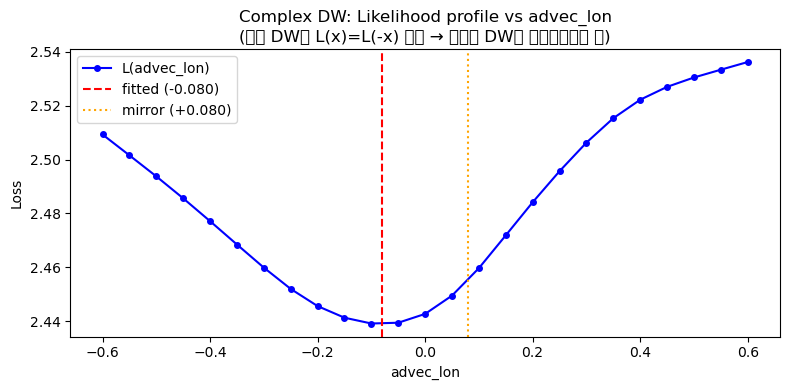

  L(fitted)  = 2.439150
  L(mirror)  = 2.459694
  Δ          = +0.020544
  Symmetry broken: True  (✓ complex DW works)


In [7]:
import matplotlib.pyplot as plt

if results_summary:
    res = results_summary[0]
    p_base = torch.cat([p for p in res['params_list']]).detach()
    I_samp = res['I_sample']
    t_auto = res['taper_autocorr']
    n1, n2, p_time = res['n1'], res['n2'], res['p_time']

    advec_lon_range = np.linspace(-0.6, 0.6, 25)
    losses = []

    print("Sweeping advec_lon...")
    for v in advec_lon_range:
        p_test = p_base.clone()
        p_test[5] = float(v)
        loss_v = dwl.whittle_likelihood_loss_tapered(
            p_test, I_samp, n1, n2, p_time, t_auto, DELTA_LAT, DELTA_LON
        ).item()
        losses.append(loss_v)
    print("Done.")

    fitted_lon = p_base[5].item()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(advec_lon_range, losses, 'b-o', ms=4, label='L(advec_lon)')
    ax.axvline(fitted_lon, color='red', ls='--', label=f'fitted ({fitted_lon:+.3f})')
    ax.axvline(-fitted_lon, color='orange', ls=':', label=f'mirror ({-fitted_lon:+.3f})')
    ax.set_xlabel('advec_lon')
    ax.set_ylabel('Loss')
    ax.set_title('Complex DW: Likelihood profile vs advec_lon\n'
                 '(실수 DW는 L(x)=L(-x) 대칭 → 복소수 DW는 비대칭이어야 함)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # numerical check
    idx_fitted = np.argmin(np.abs(advec_lon_range - fitted_lon))
    idx_mirror = np.argmin(np.abs(advec_lon_range + fitted_lon))
    print(f"  L(fitted)  = {losses[idx_fitted]:.6f}")
    print(f"  L(mirror)  = {losses[idx_mirror]:.6f}")
    print(f"  Δ          = {losses[idx_mirror] - losses[idx_fitted]:+.6f}")
    symmetry_broken = abs(losses[idx_mirror] - losses[idx_fitted]) > 1e-4
    print(f"  Symmetry broken: {symmetry_broken}  ({'✓ complex DW works' if symmetry_broken else '✗ still symmetric'})")

## 6. 진단 4: Im/Re ratio of F_01 vs advec_lon

`advec_lon`이 클수록 `|Im(F_01)| / |Re(F_01)|`이 커짐을 확인
→ advec=0이면 F는 실수 (부호 구분 불가), advec≠0이면 F가 복소수 (부호 구분 가능)

In [8]:
if results_summary:
    res = results_summary[0]
    p_base = torch.cat([p for p in res['params_list']]).detach()
    n1, n2, p_time = res['n1'], res['n2'], res['p_time']

    test_advec_lons = [0.0, 0.05, 0.10, 0.1689, 0.30, -0.1689]
    print(f"  {'advec_lon':>12}  {'mean|Im(F_01)|':>16}  {'mean|Re(F_01)|':>16}  {'Im/Re ratio':>12}")
    print(f"  {'-'*60}")

    for v in test_advec_lons:
        p_test = p_base.clone()
        p_test[5] = float(v)
        F = dwl.expected_periodogram_fft_tapered(
            p_test, n1, n2, p_time, res['taper_autocorr'], DELTA_LAT, DELTA_LON
        )
        F_01 = F[:, :, 0, 1]
        im_mean = F_01.imag.abs().mean().item()
        re_mean = F_01.real.abs().mean().item()
        ratio   = im_mean / (re_mean + 1e-15)
        print(f"  {v:>12.4f}  {im_mean:>16.6f}  {re_mean:>16.6f}  {ratio:>12.4f}")

    print("\n  advec_lon=0 → Im≈0 (실수 DW와 동일)")
    print("  advec_lon≠0 → Im>0 (복소수 구조 존재 → 부호 구분 가능)")

     advec_lon    mean|Im(F_01)|    mean|Re(F_01)|   Im/Re ratio
  ------------------------------------------------------------
        0.0000          0.002732          0.010762        0.2538
        0.0500          0.005706          0.009067        0.6294
        0.1000          0.007417          0.007255        1.0222
        0.1689          0.007792          0.006638        1.1738
        0.3000          0.007395          0.006882        1.0746
       -0.1689          0.007013          0.007389        0.9492

  advec_lon=0 → Im≈0 (실수 DW와 동일)
  advec_lon≠0 → Im>0 (복소수 구조 존재 → 부호 구분 가능)


## 7. 전체 결과 요약

In [9]:
print(f"{'='*60}")
print(f"  Complex DW fitting summary")
print(f"{'='*60}")
print(f"  {'Day':>5}  {'Loss':>10}  {'advec_lat':>12}  {'advec_lon':>12}")
print(f"  {'-'*48}")
for res in results_summary:
    p = torch.cat([pp for pp in res['params_list']]).detach()
    print(f"  {res['day']:>5}  {res['loss']:>10.5f}  {p[4].item():>12.4f}  {p[5].item():>12.4f}")
print(f"\n  Note: log-det term is identical for ±advec (det invariant under conjugation)")
print(f"  Sign discrimination comes ONLY from trace term tr(F⁻¹ · I_sample)")

  Complex DW fitting summary
    Day        Loss     advec_lat     advec_lon
  ------------------------------------------------
     14      2.4390        0.0245       -0.0800

  Note: log-det term is identical for ±advec (det invariant under conjugation)
  Sign discrimination comes ONLY from trace term tr(F⁻¹ · I_sample)
